# Regression

In [218]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context("paper")

regression_model_comparison = pd.read_csv("/home/er8813ha/immunopeptides/plots_v1/regression/model_comparison.csv")
regression_rf_importance = pd.read_csv("/home/er8813ha/immunopeptides/plots_v1/regression/rf_feature_importance.csv")
regression_train_predictions = pd.read_csv("/home/er8813ha/immunopeptides/plots_v1/regression/train_predictions.csv")
regression_val_predictions = pd.read_csv("/home/er8813ha/immunopeptides/plots_v1/regression/val_predictions.csv")
regression_symbolic_equations = pd.read_csv("/home/er8813ha/immunopeptides/plots_v1/regression/symbolic_regression_all_equations.csv")

regression_colors = "Blues_r"

In [217]:
regression_val_predictions.head()

,complex_filename,y_val,lasso_pred,rf_pred,svr_pred,symbolic_pred
0,1sl3_DFEEIPEELA,11.853872,6.584686,8.046226,6.184265,6.412280
1,3ipq_SLTERHKILHRLLQE,7.568636,7.325022,7.030612,7.336970,7.704805
2,4b1y_KREIKRRLTRKLSQRPTVEELRERKILIRF,6.568636,7.084721,7.028201,7.480538,7.035916
3,4rey_SNPCIPFFYRADENDEVKITVI,6.966576,7.625854,7.698275,6.994011,6.915003
4,4k4j_KHKILHRLLQD,6.123782,7.105062,7.731989,7.242355,7.523749


In [226]:
regression_model_comparison

,Model,best_alpha,train_kendall_tau,train_mae,train_pearson_r,train_r2,train_rmse,train_spearman_r,train_top_k_accuracy_true,val_kendall_tau,val_mae,val_pearson_r,val_r2,val_rmse,val_spearman_r,val_top_k_accuracy_true
0,Lasso,0.007565,0.328283,1.133039,0.485986,0.233216,1.437496,0.467083,0.4,0.200388,1.345380,0.346919,0.109023,1.729579,0.262259,0.4
1,RF,NaN,0.853069,0.457781,0.972308,0.877892,0.573643,0.969036,0.8,0.279768,1.357350,0.443668,0.187153,1.652006,0.407759,0.5
2,SVR,NaN,0.389502,1.023540,0.508996,0.258633,1.413470,0.531179,0.5,0.134560,1.416051,0.212002,-0.013804,1.844948,0.169309,0.3
3,Symbolic,NaN,0.314146,1.149345,0.463165,0.214522,1.454913,0.448406,0.3,0.148113,1.333363,0.333976,0.086820,1.750997,0.232098,0.4


/srv/data1/er8813ha/.tmp/ipykernel_993806/4245604983.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(regression_model_comparison, x="Model", y="val_pearson_r", palette="Blues_r")


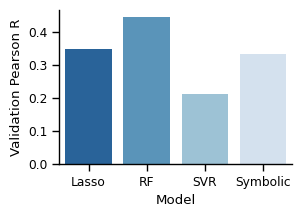

In [235]:
plt.figure(figsize=(3,2))
model_colors = {model: color for model, color in zip(["lasso", "rf", "symbolic", "svr"], sns.color_palette(regression_colors, n_colors=4))}

sns.barplot(regression_model_comparison, x="Model", y="val_pearson_r", palette="Blues_r")
sns.despine()
plt.xlabel("Model")
plt.ylabel("Validation Pearson R")
plt.savefig("./plots/regression_model_comparison.svg", bbox_inches='tight', dpi=300)

/srv/data1/er8813ha/.tmp/ipykernel_993806/843681582.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regression_rf_importance.head(10), x="Feature", y="Importance", palette="Blues_r")


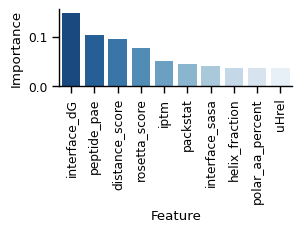

In [206]:
plt.figure(figsize=(3,1))
sns.barplot(data=regression_rf_importance.head(10), x="Feature", y="Importance", palette="Blues_r")
plt.xticks(rotation=90)
sns.despine()
plt.savefig("./plots/regression_rf_feature_importance.svg", bbox_inches='tight', dpi=300)

In [207]:
regression_symbolic_equations

,equation,complexity,loss,score,train_rmse,train_r2,val_rmse,val_r2,val_mae,equation_index
0,hydrophobic_aa_percent + (5.8235598 - 10.17272...,29,1.729807,0.007283,1.315222,3.581139e-01,2.004212,-0.196391,1.465812,14
1,(distance_score*(distance_score + uHrel)*(dist...,27,1.755186,0.007425,1.324835,3.486964e-01,1.974001,-0.160594,1.468881,13
2,(5.6663017 - 9.906607*interface_dG)*(distance_...,25,1.781446,0.015483,1.334709,3.389520e-01,1.922956,-0.101348,1.451127,12
3,uHrel + (5.2653885 - 9.166121*interface_dG)*(d...,23,1.837474,0.010444,1.355535,3.181617e-01,1.857456,-0.027597,1.381420,11
4,(5.2525964 - 9.180944*interface_dG)*(distance_...,21,1.876259,0.014529,1.369766,3.037695e-01,1.896907,-0.071711,1.428060,10
5,distance_score*(5.8982673 - 10.134738*interfac...,19,1.931580,0.011956,1.389813,2.832412e-01,1.915409,-0.092720,1.472947,9
6,(4.0069532 - 6.3956246*interface_dG)*(instabil...,17,1.978326,0.006529,1.406530,2.658953e-01,1.776957,0.059542,1.367936,8
7,(5.272202 - 8.362269*interface_dG)*(hydrophobi...,15,2.004328,0.006872,1.415743,2.562467e-01,1.773129,0.063589,1.343831,7
8,(4.0068793 - 6.345113*interface_dG)*(distance_...,13,2.032063,0.020420,1.425505,2.459546e-01,1.764895,0.072266,1.344039,6
9,(3.374078 - 4.3519845*interface_dG)*(distance_...,11,2.116772,0.008267,1.454913,2.145215e-01,1.750997,0.086820,1.333363,5


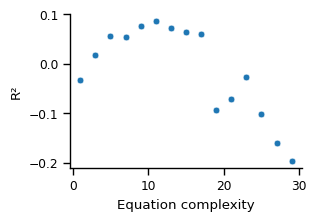

In [208]:
plt.figure(figsize=(3,2))
sns.scatterplot(data=regression_symbolic_equations, x="complexity", y="val_r2", color="tab:blue")
sns.despine()
plt.xlabel("Equation complexity")
plt.ylabel("R²")
plt.savefig("./plots/regression_symbolic_equation_complexity.svg", bbox_inches='tight', dpi=300)

In [209]:
test_decoy_predictions = pd.read_csv("/home/er8813ha/immunopeptides/plots_v1/test/decoy_predictions.csv")
test_real_predictions = pd.read_csv("/home/er8813ha/immunopeptides/plots_v1/test/test_predictions.csv")
test_real_predictions["data_type"] = "real"
test_decoy_predictions["y_pred"] = test_decoy_predictions["prediction"]
test_predictions = pd.concat([test_real_predictions, test_decoy_predictions], ignore_index=True)
test_predictions.head()

,complex_filename,y_true,y_pred,data_type,prediction
0,5b76_ARTKQTARKSTGGAPRKQLATKAA,5.236572,4.064015,real,NaN
1,1c5x_LKFQCGQKT,6.677781,5.229994,real,NaN
2,5mwp_KSLLQQLLTE,7.500313,7.433888,real,NaN
3,5b75_ARTKQTARKSTGGAPRKQLATKAA,5.000000,4.413881,real,NaN
4,2pon_GGTMENLSRRLKVTGDLFDIMSG,5.853872,6.847807,real,NaN


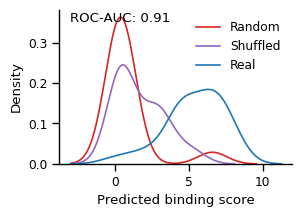

In [210]:
plt.figure(figsize=(3,2))
sns.kdeplot(data=test_predictions, x="y_pred", hue="data_type", palette=["tab:blue", "tab:purple", "tab:red"], common_norm=False)
sns.despine()
plt.legend( labels=["Random", "Shuffled", "Real"], loc='upper right', frameon=False)
plt.annotate("ROC-AUC: 0.91", xy=(-3, 0.35), xycoords='data' )
plt.xlabel("Predicted binding score")
plt.savefig("./plots/test_set_prediction_distribution.svg", bbox_inches='tight', dpi=300)

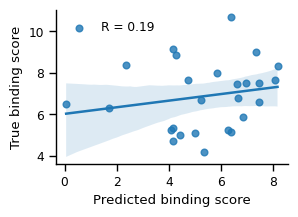

In [236]:
plt.figure(figsize=(3,2))
pearson = pearsonr(test_real_predictions["y_true"], test_real_predictions["y_pred"])

sns.regplot(data=test_real_predictions, x="y_pred", y="y_true", label=f"R = {pearson.correlation:.2f}")
sns.despine()
plt.xlabel("Predicted binding score")
plt.ylabel("True binding score")
plt.legend(loc='upper left', frameon=False)
plt.savefig("./plots/test_set_prediction_correlation.svg", bbox_inches='tight', dpi=300)

# Classification

In [212]:
classification_model_comparison = pd.read_csv("/home/er8813ha/immunopeptides/plots_v1/classification/model_comparison.csv")
classification_rf_importance = pd.read_csv("/home/er8813ha/immunopeptides/plots_v1/classification/rf_feature_importance.csv")
classification_train_predictions = pd.read_csv("/home/er8813ha/immunopeptides/plots_v1/classification/train_predictions.csv")
classification_train_probabilities = pd.read_csv("/home/er8813ha/immunopeptides/plots_v1/classification/train_probabilities.csv")
classification_val_predictions = pd.read_csv("/home/er8813ha/immunopeptides/plots_v1/classification/val_predictions.csv")
classification_val_probabilities = pd.read_csv("/home/er8813ha/immunopeptides/plots_v1/classification/val_probabilities.csv")
classification_symbolic_equations = pd.read_csv("/home/er8813ha/immunopeptides/plots_v1/classification/symbolic_classification_all_equations.csv")

In [213]:
classification_val_probabilities

,complex_filename,y_val,logreg_proba,rf_proba,svc_proba,symbolic_proba
0,4q5u_RRRFRAARKSKVINIVAVLKGIEM,0,0.306556,0.303861,0.204298,0.172262
1,1ydr_ARATIDYNTRSDGTHRFGIA,0,0.275797,0.028568,0.098241,0.133964
2,1ssc_IRENNRGIRESGSDAI,0,0.409593,0.312038,0.351298,0.405347
3,1gl0_TVLCMCTTCQGQWPTDNKQPPCVCTTGGKQCG,0,0.473610,0.345957,0.527059,0.502749
4,5f74_RLRRVYQINKNAWYIQWADI,0,0.265893,0.213039,0.139161,0.166868
...,...,...,...,...,...,...
90,2lpb_STDSTPMFEYENLEDNSKEWTSLFDNDIPVTTDD,1,0.273336,0.441189,0.374346,0.345849
91,4z84_TTYADFIASGRTGRRNAIHD,1,0.730612,0.999563,0.876738,0.831394
92,2o4j_KNHPMLMNLLKD,1,0.716409,0.817391,0.856935,0.954925
93,5b78_ARTKQTARKSTGGAPRKQLAT,1,0.665630,0.857970,0.882168,0.862863


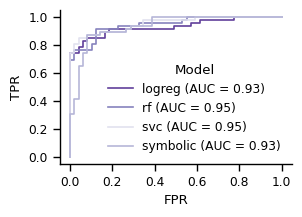

In [220]:
from sklearn.metrics import roc_auc_score, roc_curve
classification_colors = "Purples_r"
model_colors = {model: color for model, color in zip(["logreg", "rf", "symbolic", "svc"], sns.color_palette(classification_colors, n_colors=4))}
plt.figure(figsize=(3,2))
for model in ["logreg", "rf", "svc", "symbolic"]:
    y_true = classification_val_predictions["y_val"]
    y_scores = classification_val_probabilities[f"{model}_proba"]
    auc = roc_auc_score(y_true, y_scores)
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    plt.plot(fpr, tpr, label=f"{model} (AUC = {auc:.2f})", color=model_colors[model])
plt.legend(title="Model", loc='lower right', frameon=False)
sns.despine()
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.savefig("./plots/classification_model_comparison.svg", bbox_inches='tight', dpi=300)

/srv/data1/er8813ha/.tmp/ipykernel_993806/2874496155.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=classification_rf_importance.head(10), x="Feature", y="Importance", palette="Purples_r")


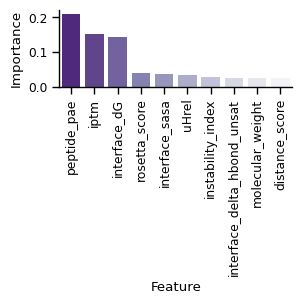

In [215]:
plt.figure(figsize=(3,1))
sns.barplot(data=classification_rf_importance.head(10), x="Feature", y="Importance", palette="Purples_r")
plt.xticks(rotation=90)
sns.despine()
plt.savefig("./plots/classification_rf_feature_importance.svg", bbox_inches='tight', dpi=300)

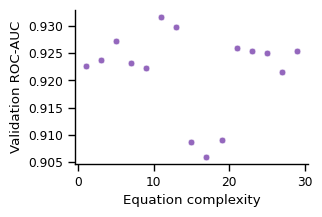

In [216]:
plt.figure(figsize=(3,2))
sns.scatterplot(data=classification_symbolic_equations, x="complexity", y="val_auc", color="tab:purple")
plt.xlabel("Equation complexity")
plt.ylabel("Validation ROC-AUC")
sns.despine()
plt.savefig("./plots/classification_symbolic_equation_complexity.svg", bbox_inches='tight', dpi=300)